## Experiment 15 — Image Segmentation Using K-Means\n\n*This cell opens an upload dialog — run it in Colab and select an image file from your computer when prompted.*

Saving images.jpeg to images.jpeg


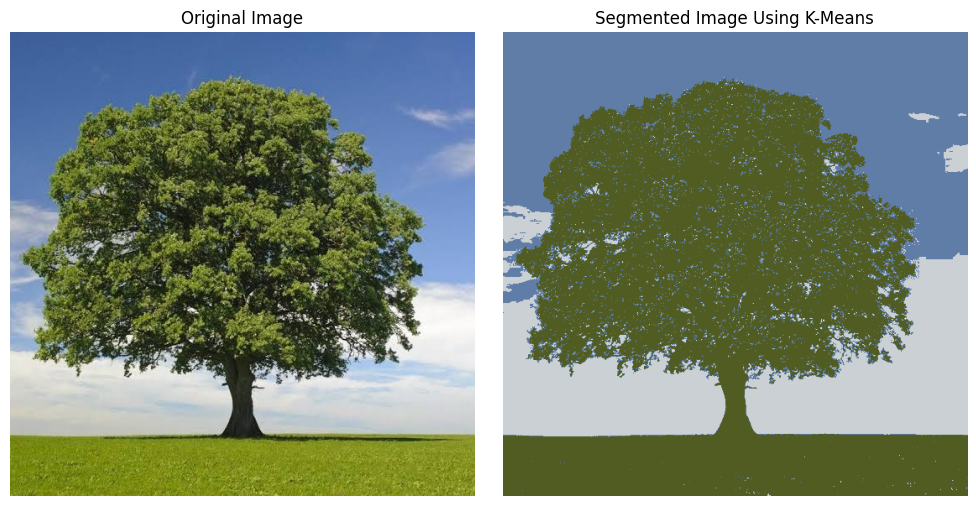

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError("The image could not be loaded.")

rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pixels = np.float32(
    rgb_img.reshape((-1, 3))
)

criteria = (
    cv2.TERM_CRITERIA_EPS
    + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)

K = 3

compactness, labels, centers = cv2.kmeans(
    pixels,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

centers = np.uint8(centers)

segmented_img = centers[
    labels.flatten()
].reshape(rgb_img.shape)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title("Segmented Image Using K-Means")
plt.axis("off")

plt.tight_layout()
plt.show()